# 03 – Dataset Preparation

In this notebook, we prepare a dataset for music genre classification by converting audio files into Mel-spectrograms and assigning labels.

> Note: All examples are based on a small subset of the dataset for demonstration purposes.
## Goals

By the end of this notebook, we can:

- load multiple audio files from a dataset  
- assign labels based on folder structure  
- extract Mel-spectrogram features  
- ensure consistent input shapes  
- build an initial dataset (X, y) for machine learning  

In [15]:
from pathlib import Path
from collections import Counter


import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


We use `librosa` for audio processing and `matplotlib` for visualization.

## 1. Load Dataset

First, we define the path to the dataset and inspect its structure.

In [16]:
data_path = Path("../data/raw/gtzan/Data/genres_original")
genres = [d.name for d in data_path.iterdir() if d.is_dir()]
print(genres)

['rock', 'pop', 'country', 'disco', 'reggae', 'metal', 'hiphop', 'jazz', 'classical', 'blues']


### Dataset Structure

The dataset is organized into folders, where each folder represents a music genre.

Each audio file inside a folder inherits the folder name as its label.

## 2. Create File Paths and Labels

We iterate through selected genres and collect file paths and corresponding labels.

In [17]:
genres = genres[:2]  # only use a subset for testing
file_paths = []
labels = []

for genre in genres:
    genre_path = data_path / genre
    
    files = list(genre_path.glob("*.wav"))[:5] 
    
    for file in files:
        file_paths.append(file)
        labels.append(genre)

print("Total samples:", len(file_paths))
print("Label distribution:", Counter(labels))

Total samples: 10
Label distribution: Counter({'rock': 5, 'pop': 5})


This creates a supervised learning dataset where each audio file is paired with a genre label.

## 3. Feature Extraction: Mel-Spectrogram

To make audio data usable for machine learning, we convert each audio file into a Mel-spectrogram.

In [18]:
def compute_mel(file_path):
    y, sr = librosa.load(file_path, sr=22050)
    
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128
    )
    
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    return mel_db

The function `compute_mel()` standardizes the feature extraction process for all audio files.

## 4. Build Dataset

We now convert all audio files into Mel-spectrograms and store them together with their labels.

In [19]:
X = []
y = []

for file, label in zip(file_paths, labels):
    mel = compute_mel(file)
    
    # enforce consistent shape
    if mel.shape[1] >= 130:
        mel = mel[:, :130]
        X.append(mel)
        y.append(label)

print("Final dataset size:", len(X))

Final dataset size: 10


## 5. Ensuring Consistent Input Shape

Machine learning models require all inputs to have the same shape.

Since audio files vary in length, we trim all spectrograms to a fixed size.

In more advanced pipelines, padding or segmentation could also be used.

## 6. Final Dataset Representation

In [20]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10, 128, 130)
y shape: (10,)


The dataset is now structured as:

- `X`: Mel-spectrograms (input features)  
- `y`: corresponding genre labels  

Each sample can be interpreted as a 2D image, making it suitable for machine learning models such as CNNs.

## 7. Label Encoding

Machine learning models require numerical labels instead of strings.

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['pop' 'rock']


## 8. Feature Normalization

Normalization ensures that all features are on a similar scale, which improves training stability.

In [22]:
X = (X - np.mean(X)) / np.std(X)

## 9. Dataset Inspection

We visualize example Mel-spectrograms to verify the preprocessing pipeline.

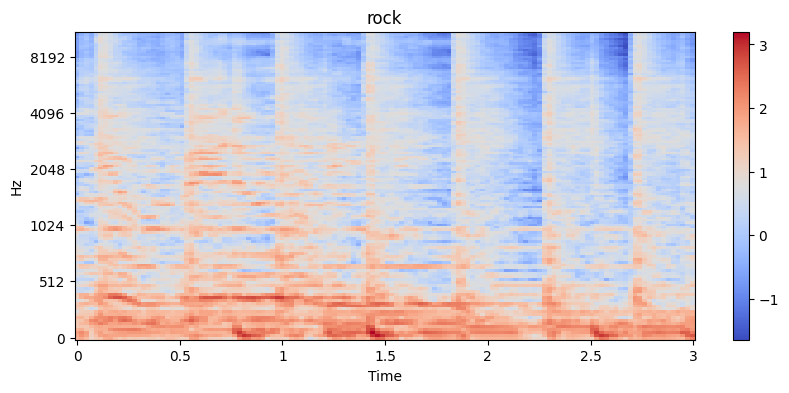

In [23]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(X[0], x_axis='time', y_axis='mel')
plt.title(y[0])
plt.colorbar()
plt.show()

These visual differences suggest that machine learning models may be able to distinguish genres based on their patterns.

### Strucuture of the Dataset
Before using the dataset for machine learning, it is important to inspect its structure.

We check:

- the shape of a single sample  
- the associated labels  

This helps verify that the preprocessing pipeline produced consistent and meaningful data.

In [24]:
print("Shape of one sample:", X[0].shape)
print("Genre:",y[:5])

Shape of one sample: (128, 130)
Genre: ['rock' 'rock' 'rock' 'rock' 'rock']


Each sample represents a Mel-spectrogram with fixed dimensions, which is required for machine learning models.

## 10 Visualizing Samples per Genre

To better understand the dataset, we visualize one example Mel-spectrogram for each genre.

This allows us to:

- verify that the feature extraction works correctly  
- compare patterns across different genres  
- gain intuition about what the model will later learn  

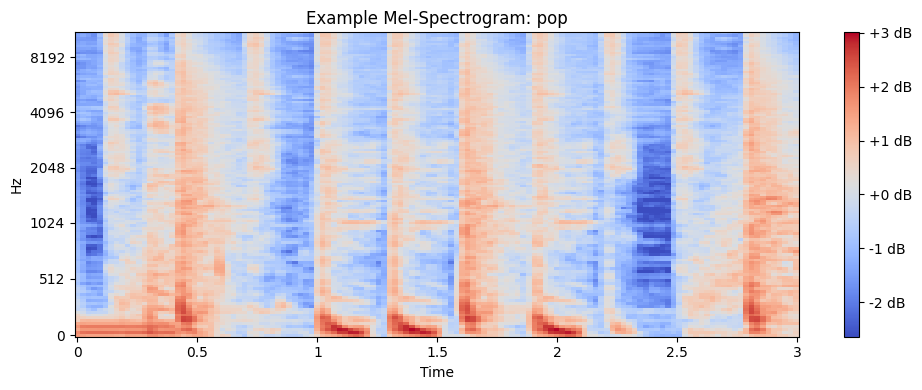

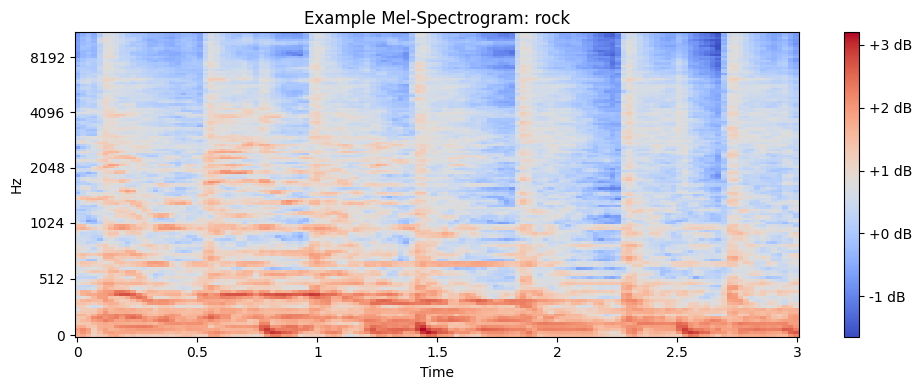

In [25]:
unique_labels = np.unique(y)

for label in unique_labels:
    index = np.where(y == label)[0][0]
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(X[index], x_axis="time", y_axis="mel")
    plt.title(f"Example Mel-Spectrogram: {label}")
    plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    plt.show()

Even with a small dataset, we can already observe differences in the time–frequency structure between genres.  
These patterns form the basis for machine learning models to distinguish between classes.  
This step is an important sanity check before training a model.

## Observations

- Multiple audio files were successfully converted into Mel-spectrograms.
- Each sample is associated with a genre label, forming a supervised learning dataset.
- All spectrograms have a consistent shape, which is required for machine learning models.
- The dataset structure (X, y) follows a standard format used in machine learning workflows.

## Limitations

This notebook uses only a small subset of the dataset: 2 genres with 5 songs each.  
While useful for testing the preprocessing pipeline, it is not sufficient for reliable model training.

## Week 3 Summary

In this week, we built a dataset preparation pipeline for machine learning:

- Loaded multiple audio files from the dataset  
- Assigned labels based on folder structure  
- Converted audio signals into Mel-spectrograms  
- Ensured consistent input shapes  
- Created a structured dataset (X, y)  
- Prepared labels and features for machine learning  

This dataset can now be used to train models for music genre classification.